# Notebook 03b – Goal 3 mirrored on the underperformance task (target_low_perf)

**Authors:** Ivo Rambaldi & Tommaso Petrelli  
**Course:** Ethics for Artificial Intelligence, University of Bologna, a.y. 2025–2026

---

## Goal 3 — Utility and Fairness Measurement Framework

This notebook implements Goal 3 of the project:

> Auto-generated mirror of `G3.ipynb`, re-targeted at the symmetric lower-tail ("underperformance", score <= 25th percentile) detection task instead of the excellence (score >= 75th percentile) task -- following Marrero et al. (ECAI 2024), who show that fairness bias direction flips between the two tasks. All logic is identical to `G3.ipynb`; only `TARGET_COL` and the output paths differ (see the config cell below), so results are directly comparable side by side.

### Structure

1. **Setup** — imports, config, constants  
2. **Data loading** — reconstruct `DataSplit` from Goal 1 outputs; binarise protected attributes; encode features  
3. **Synthetic data loading** — load Goal 2 outputs; align feature schema  
4. **Real-data baseline validation** — run `Evaluator.baseline()` for all three classifiers  
5. **TSTR evaluation loop** — full `(generator × classifier)` matrix  
6. **Utility analysis** — tables and bar charts of BA / F1 / AUC and MMD  
7. **Fairness analysis** — DPD / EOD / DI tables, per-attribute plots, delta heatmaps  
8. **Fairness mitigation** — equalized-odds and prejudice-remover training, one protected attribute at a time, still under TSTR  
9. **Summary**

## 1 · Setup

In [79]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")

from src.utils import get_logger, load_config
from src.data.preprocessor import DataSplit, save_split
from src.models.classifiers import build_classifier, CLASSIFIER_DISPLAY_NAMES
from src.evaluation.evaluator import Evaluator, MitigatedEvaluator
from src.evaluation.delta import compute_delta_matrix, get_fairness_delta_columns
from src.utils import (
    plot_utility_bar,
    plot_fairness_bar,
    plot_mmd_bar,
    plot_delta_heatmap,
    plot_utility_fairness_scatter,
    plot_per_attribute_fairness,
    plot_class_balance,
)

logger = get_logger("notebook_03")

In [80]:
cfg = load_config()

TARGET_COL  = cfg["target"]["low_column_name"]         # "target_low_perf" (Goal 3b)
cfg["dataset"]["target_column"] = TARGET_COL           # keep src/ modules (which read
                                                        # dataset.target_column) in sync

# Route every saved figure/CSV to a dedicated sub-directory so this run never
# overwrites the target_high_perf results produced by G3.ipynb.
cfg["paths"]["figures_dir"] = cfg["paths"]["figures_dir"] / "low_perf"
cfg["paths"]["results_dir"] = cfg["paths"]["results_dir"] / "low_perf"
SEED        = cfg["seed"]
CLASSIFIERS = list(CLASSIFIER_DISPLAY_NAMES.keys())

METHODS     = ["ctgan", "tvae", "gaussian_copula", "smote_low_perf"]  # low-perf variant swaps SMOTE

BASELINE    = cfg["experiments"]["baseline_label"]

# Protected attributes for fairness evaluation — single source of truth in config.yaml
PROTECTED_ATTRS = cfg["dataset"]["protected_attributes"]

print(f"Target       : {TARGET_COL}")
print(f"Classifiers  : {CLASSIFIERS}")
print(f"Gen. methods : {METHODS}")
print(f"Protected    : {PROTECTED_ATTRS}")
print(f"Seed         : {SEED}")

Target       : target_low_perf
Classifiers  : ['logistic_regression', 'xgboost', 'mlp']
Gen. methods : ['ctgan', 'tvae', 'gaussian_copula', 'smote_low_perf']
Protected    : ['s_gender', 's_birth_country', 'f_mother_education_level', 'f_father_education_level', 'f_mother_occupation', 'f_father_occupation', 'f_extent_of_books_at_home', 'f_frequency_of_see_adult_read', 'p_public_or_private', 'p_island', 'p_percentage_of_teachers_changed_school_last_year', 'f_ESCS']
Seed         : 42


## 2 · Data Loading & DataSplit Construction

We load the train / test CSVs produced by Notebook 01, slice out the protected
attribute columns configured in `config.yaml` (`dataset.protected_attributes`),
and apply a consistent OrdinalEncoder + StandardScaler (fit on the real
training set only) to build the `DataSplit` that the `Evaluator` expects.

### Protected attributes

We pass the **raw, un-binarised** protected-attribute columns straight through.
`src/evaluation/fairness.py` already auto-binarises any attribute at evaluation
time (`_binarise_attribute`: direct mapping for already-binary columns, median
split for ordinal/continuous ones such as `f_ESCS`), so no manual binarisation
step is needed here.

In [81]:
train_df = pd.read_csv(cfg["paths"]["train_data"])
test_df  = pd.read_csv(cfg["paths"]["test_data"])

print(f"Train : {train_df.shape}   Test : {test_df.shape}")
print(f"\nClass balance (train):\n{train_df[TARGET_COL].value_counts(normalize=True).round(3)}")
print(f"\nClass balance (test):\n{test_df[TARGET_COL].value_counts(normalize=True).round(3)}")

Train : (58128, 42)   Test : (14533, 42)

Class balance (train):
target_low_perf
0    0.75
1    0.25
Name: proportion, dtype: float64

Class balance (test):
target_low_perf
0    0.749
1    0.251
Name: proportion, dtype: float64


In [82]:
present_attrs = [a for a in PROTECTED_ATTRS if a in train_df.columns]
missing_attrs = [a for a in PROTECTED_ATTRS if a not in train_df.columns]
if missing_attrs:
    print(f"  WARNING: {len(missing_attrs)} configured protected attributes "
          f"not present in the data — skipping: {missing_attrs}")

protected_train = train_df[present_attrs].copy()
protected_test  = test_df[present_attrs].copy()

for attr in protected_train.columns:
    print(f"\n{attr}:")
    print(f"  Train: {protected_train[attr].value_counts(dropna=False).to_dict()}")
    print(f"  Test : {protected_test[attr].value_counts(dropna=False).to_dict()}")


s_gender:
  Train: {'MALE': 29356, 'FEMALE': 28772}
  Test : {'MALE': 7482, 'FEMALE': 7051}

f_mother_education_level:
  Train: {nan: 16166, 4.0: 10973, 3.0: 9504, 5.0: 5578, 7.0: 4987, 2.0: 4753, 6.0: 4399, 8.0: 1084, 9.0: 422, 1.0: 262}
  Test : {nan: 4163, 4.0: 2658, 3.0: 2322, 5.0: 1438, 7.0: 1240, 2.0: 1195, 6.0: 1048, 8.0: 296, 9.0: 117, 1.0: 56}

f_father_education_level:
  Train: {nan: 19027, 4.0: 9950, 3.0: 9948, 2.0: 6409, 5.0: 4350, 7.0: 3687, 6.0: 2953, 8.0: 896, 9.0: 478, 1.0: 430}
  Test : {nan: 4926, 4.0: 2481, 3.0: 2395, 2.0: 1584, 5.0: 1116, 7.0: 900, 6.0: 738, 8.0: 192, 9.0: 114, 1.0: 87}

f_mother_occupation:
  Train: {3.0: 23110, nan: 17842, 4.0: 8923, 2.0: 6887, 1.0: 1366}
  Test : {3.0: 5844, nan: 4587, 4.0: 2105, 2.0: 1661, 1.0: 336}

f_father_occupation:
  Train: {3.0: 22155, nan: 20193, 4.0: 9817, 2.0: 5654, 1.0: 309}
  Test : {3.0: 5495, nan: 5223, 4.0: 2314, 2.0: 1412, 1.0: 89}

f_extent_of_books_at_home:
  Train: {0.25: 17033, nan: 15018, 0.5: 9761, 0.0: 70

In [83]:
def make_feature_matrix(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """Drop target + any leftover was_nan flag columns that shouldn't be features.

    Both target_high_perf and target_low_perf live in the same saved CSV
    (Notebook 01 builds both), so the *inactive* target must be dropped too --
    otherwise it would leak into the feature set as a near-perfect predictor.
    """
    other_targets = [cfg["target"]["column_name"], cfg["target"]["low_column_name"]]
    drop_cols = [target_col] + other_targets + [c for c in df.columns if c.endswith("_was_nan")]
    return df.drop(columns=[c for c in drop_cols if c in df.columns])


X_train_raw = make_feature_matrix(train_df, TARGET_COL)
X_test_raw  = make_feature_matrix(test_df,  TARGET_COL)
y_train     = train_df[TARGET_COL].astype(int)
y_test      = test_df[TARGET_COL].astype(int)

print(f"X_train : {X_train_raw.shape}   X_test : {X_test_raw.shape}")
print(f"Positive rate — train: {y_train.mean():.1%}  test: {y_test.mean():.1%}")

X_train : (58128, 33)   X_test : (14533, 33)
Positive rate — train: 25.0%  test: 25.1%


### Feature encoding

Logistic Regression and MLP require fully numerical input; XGBoost also benefits
from it when using the sklearn wrapper. We apply:

- **OrdinalEncoder** (fit on X_train) to all `object`-dtype columns  
- **StandardScaler** (fit on X_train) to all numerical columns  

The fitted transformers are stored in `DataSplit.encoders` and `DataSplit.scaler`
so they can be applied to synthetic data in the same way.

In [84]:
from src.data.preprocessor import fit_feature_encoders, apply_feature_encoders

enc, scaler, cat_cols, num_cols = fit_feature_encoders(X_train_raw)
X_train = apply_feature_encoders(X_train_raw, enc, scaler, cat_cols, num_cols)
X_test  = apply_feature_encoders(X_test_raw,  enc, scaler, cat_cols, num_cols)

print(f"Encoded X_train: {X_train.shape}  (cat={len(cat_cols)}, num={len(num_cols)})")
print(f"Any NaNs remaining: {X_train.isna().any().any()}")

Encoded X_train: (58128, 33)  (cat=1, num=32)
Any NaNs remaining: False


In [85]:
FEATURE_NAMES  = X_train.columns.tolist()
PROTECTED_COLS = [c for c in PROTECTED_ATTRS if c in protected_train.columns]

split = DataSplit(
    X_train        = X_train,
    X_test         = X_test,
    y_train        = y_train,
    y_test         = y_test,
    protected_train= protected_train[PROTECTED_COLS],
    protected_test = protected_test[PROTECTED_COLS],
    feature_names  = FEATURE_NAMES,
    target_name    = TARGET_COL,
    protected_attrs= PROTECTED_COLS,
    encoders       = {"ordinal": enc},
    scaler         = scaler,
)

# Persist for downstream notebooks (Goal 4 / 5)
save_split(split, cfg["paths"]["processed_data"].parent / "data_split_low_perf.pkl")
print("DataSplit built and saved.")
print(f"  X_train      : {split.X_train.shape}")
print(f"  X_test       : {split.X_test.shape}")
print(f"  Protected    : {PROTECTED_COLS}")

2026-07-10 20:05:46 | INFO     | src.data.preprocessor | DataSplit saved to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\Data\data_split_low_perf.pkl.
DataSplit built and saved.
  X_train      : (58128, 33)
  X_test       : (14533, 33)
  Protected    : ['s_gender', 'f_mother_education_level', 'f_father_education_level', 'f_mother_occupation', 'f_father_occupation', 'f_extent_of_books_at_home', 'f_frequency_of_see_adult_read', 'f_ESCS']


## 3 · Load Synthetic Datasets (Goal 2 outputs)

We load the four CSV files produced by Notebook 02, align their column schema to
the real training set (inner join on feature names), and apply the same
OrdinalEncoder + StandardScaler fitted above.

> **Note:** SMOTE produces an oversampled dataset that includes all original
> training rows plus new synthetic minority-class rows, so its size will differ
> from the other generators.

In [86]:
from src.utils.config import get_synthetic_output_path


def load_synthetic(method: str) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """Load synthetic CSV, encode features, return (X_synth, y_synth, protected_synth).

    protected_synth holds the RAW (unencoded) protected-attribute columns from
    the synthetic CSV, row-aligned with X_synth/y_synth. Needed by the
    mitigation loop below: a synthetic training set can have a different row
    count than the real training set (e.g. SMOTE's class-balanced output), so
    split.protected_train can't be reused for it -- each source must carry its
    own protected-attribute values.
    """
    path = get_synthetic_output_path(cfg, method)
    if not path.exists():
        raise FileNotFoundError(
            f"Synthetic data not found at {path}.\n"
            f"Run Notebook 02 first to generate it."
        )
    df = pd.read_csv(path)

    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' missing from {path}.")

    y_synth = df[TARGET_COL].astype(int)

    # Keep only features present in the real training set
    feat_cols = [c for c in FEATURE_NAMES if c in df.columns]
    missing   = set(FEATURE_NAMES) - set(df.columns)
    if missing:
        print(f"  [{method}] WARNING: {len(missing)} feature cols absent "
              f"from synthetic data — filled with 0.")

    X_synth_raw = pd.DataFrame(index=df.index)
    for col in FEATURE_NAMES:
        X_synth_raw[col] = df[col] if col in df.columns else 0.0

    X_synth = apply_feature_encoders(X_synth_raw, enc, scaler, cat_cols, num_cols)

    protected_synth = pd.DataFrame(
        {c: (df[c] if c in df.columns else np.nan) for c in PROTECTED_COLS},
        index=df.index,
    )

    return X_synth, y_synth, protected_synth


synthetic_data: dict[str, tuple[pd.DataFrame, pd.Series, pd.DataFrame]] = {}

for method in METHODS:
    try:
        X_s, y_s, prot_s = load_synthetic(method)
        synthetic_data[method] = (X_s, y_s, prot_s)
        pos_rate = y_s.mean()
        print(f"  [{method}]  rows={len(X_s):,}   +class={pos_rate:.1%}   "
              f"cols={X_s.shape[1]}")
    except FileNotFoundError as e:
        print(f"  [{method}]  SKIPPED — {e}")

print(f"\nLoaded {len(synthetic_data)}/{len(METHODS)} synthetic datasets.")

  [ctgan]  rows=58,128   +class=38.1%   cols=33
  [tvae]  rows=58,128   +class=9.3%   cols=33
  [gaussian_copula]  rows=58,128   +class=25.0%   cols=33
  [smote_low_perf]  rows=87,192   +class=50.0%   cols=33

Loaded 4/4 synthetic datasets.


2026-07-10 20:05:47 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\class_balance.png


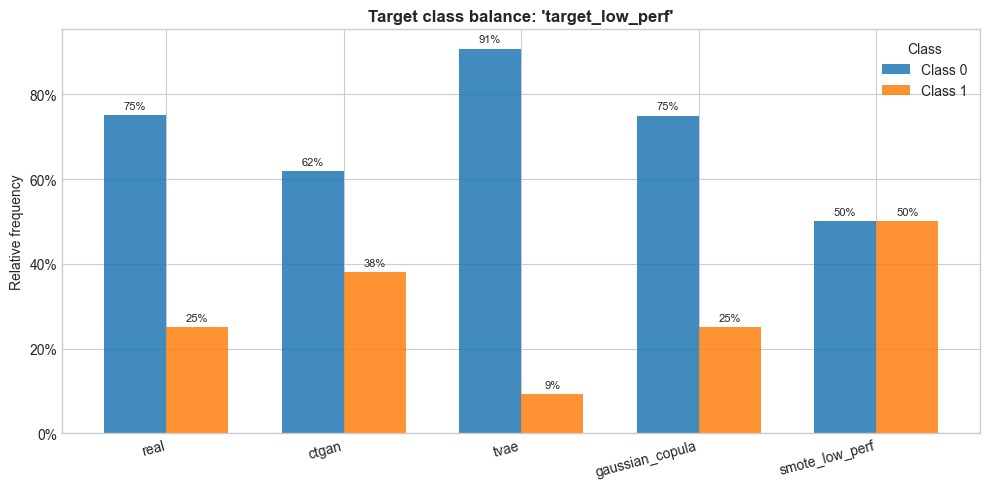

Class balance looks reasonable if synthetic proportions are close to real.


In [87]:
# Quick sanity check: class balance across all datasets
raw_synthetics_for_plot = {}
for method, (X_s, y_s, _) in synthetic_data.items():
    df_plot = X_s.copy()
    df_plot[TARGET_COL] = y_s.values
    raw_synthetics_for_plot[method] = df_plot

real_plot = X_train.copy()
real_plot[TARGET_COL] = y_train.values

_ = plot_class_balance(real_plot, raw_synthetics_for_plot, cfg, save=True)
plt.show()
print("Class balance looks reasonable if synthetic proportions are close to real.")

## 4 · Real-Data Baseline Validation

We run `Evaluator.baseline(clf)` for all three classifiers on the real training split.
This step **validates the metric pipeline**: if these numbers look reasonable for a
dataset of this size and complexity, we can trust the TSTR deltas downstream.

Expected ballpark for the Aequitas education dataset with a balanced-accuracy target:
- Logistic Regression: BA ≈ 0.65–0.75
- XGBoost: BA ≈ 0.70–0.80
- MLP: BA ≈ 0.65–0.78

In [88]:
evaluator = Evaluator(split, cfg)

baseline_rows = []
for clf_name in CLASSIFIERS:
    result = evaluator.baseline(clf_name)
    row = {
        "method"            : BASELINE,
        "classifier"        : clf_name,
        "balanced_accuracy" : result["balanced_accuracy"],
        "f1_macro"          : result["f1_macro"],
        "roc_auc"           : result["roc_auc"],
    }
    
    # Attach per-attribute fairness metrics
    for attr in PROTECTED_COLS:
        for metric in ("dpd", "eod", "di"):
            key = f"{attr}_{metric}"
            if key in result:
                row[key] = result[key]
    baseline_rows.append(row)
    print(f"  [{clf_name}]  BA={result['balanced_accuracy']:.4f}  "
          f"F1={result['f1_macro']:.4f}  AUC={result['roc_auc']:.4f}")

2026-07-10 20:05:48 | INFO     | src.evaluation.evaluator | Computing real-data baseline for [logistic_regression] …
2026-07-10 20:05:48 | INFO     | src.evaluation.evaluator |   [real] AUC=0.6856 | BA=0.6301
  [logistic_regression]  BA=0.6301  F1=0.5844  AUC=0.6856
2026-07-10 20:05:48 | INFO     | src.evaluation.evaluator | Computing real-data baseline for [xgboost] …
2026-07-10 20:05:48 | INFO     | src.evaluation.evaluator |   [real] AUC=0.7065 | BA=0.6478
  [xgboost]  BA=0.6478  F1=0.5961  AUC=0.7065
2026-07-10 20:05:48 | INFO     | src.evaluation.evaluator | Computing real-data baseline for [mlp] …
2026-07-10 20:05:56 | INFO     | src.evaluation.evaluator |   [real] AUC=0.6910 | BA=0.5406
  [mlp]  BA=0.5406  F1=0.5182  AUC=0.6910


In [89]:
baseline_df = pd.DataFrame(baseline_rows)

# Compute mean fairness metrics per classifier (across protected attrs)
for metric in ("dpd", "eod", "di", "odds_ratio"):
    cols = [c for c in baseline_df.columns
            if c.endswith(f"_{metric}") and not c.startswith(("fairness_gap", "mean_"))]
    if cols:
        baseline_df[f"mean_{metric}"] = baseline_df[cols].mean(axis=1)

display_cols = ["classifier", "balanced_accuracy", "f1_macro", "roc_auc",
                "mean_dpd", "mean_eod", "mean_di", "mean_odds_ratio"]
display_cols = [c for c in display_cols if c in baseline_df.columns]

print("Real-data baseline metrics:")
print(baseline_df[display_cols].round(4).to_string(index=False))

Real-data baseline metrics:
         classifier  balanced_accuracy  f1_macro  roc_auc  mean_dpd  mean_eod  mean_di
logistic_regression             0.6301    0.5844   0.6856    0.3210    0.3141   0.4158
            xgboost             0.6478    0.5961   0.7065    0.3920    0.4176   0.3271
                mlp             0.5406    0.5182   0.6910    0.0393    0.0736   0.3034


In [90]:
# Fairness check: flag any classifier that already violates thresholds on real data
print("\nFairness threshold checks on real data:")
print(f"  DPD > 0.1 is concerning (demographic parity violation)")
print(f"  EOD > 0.1 is concerning (equalized odds violation)")
print(f"  DI  < 0.8 is concerning (four-fifths rule violation)\n")

for _, row in baseline_df.iterrows():
    flags = []
    if "mean_dpd" in row and row["mean_dpd"] > 0.1:
        flags.append(f"mean_DPD={row['mean_dpd']:.3f}")
    if "mean_eod" in row and row["mean_eod"] > 0.1:
        flags.append(f"mean_EOD={row['mean_eod']:.3f}")
    if "mean_di"  in row and row["mean_di"]  < 0.8:
        flags.append(f"mean_DI={row['mean_di']:.3f}")
    status = "⚠️  " + ", ".join(flags) if flags else "✓ all within thresholds"
    print(f"  [{row['classifier']}]  {status}")


Fairness threshold checks on real data:
  DPD > 0.1 is concerning (demographic parity violation)
  EOD > 0.1 is concerning (equalized odds violation)
  DI  < 0.8 is concerning (four-fifths rule violation)

  [logistic_regression]  ⚠️  mean_DPD=0.321, mean_EOD=0.314, mean_DI=0.416
  [xgboost]  ⚠️  mean_DPD=0.392, mean_EOD=0.418, mean_DI=0.327
  [mlp]  ⚠️  mean_DI=0.303


## 5 · TSTR Evaluation Loop

For each `(generator, classifier)` pair:
1. Call `evaluator.baseline(clf)` to set the correct real-data reference for that classifier
2. Train classifier on synthetic data
3. Test on the real held-out test set
4. Record utility metrics, fairness metrics, MMD, and correlation deltas

This is the core Train-on-Synthetic, Test-on-Real (TSTR) framework from the proposal.

In [91]:
all_rows = baseline_rows.copy()  # seed with real baseline rows

for clf_name in CLASSIFIERS:
    # Re-run baseline for this classifier to anchor _real_metrics correctly
    evaluator.baseline(clf_name)

    for method, (X_synth, y_synth, _) in synthetic_data.items():
        logger.info(f"Evaluating [{method} | {clf_name}] ...")
        result = evaluator.evaluate(
            X_synth        = X_synth,
            y_synth        = y_synth,
            classifier_name= clf_name,
            generator_name = method,
            repetition     = 0,
            X_real_for_mmd = split.X_train,
        )
        # rename "generator" -> "method" for plotting compatibility
        row = {"method": result.pop("generator"), **result}
        all_rows.append(row)
        print(f"  [{method} | {clf_name}]  "
              f"BA={row['balanced_accuracy']:.4f}  "
              f"ΔBA={row['delta_balanced_accuracy']:+.4f}  "
              f"MMD={row['mmd']:.4f}")

print(f"\n{len(all_rows)} rows collected ({len(CLASSIFIERS)} baselines + "
      f"{len(synthetic_data) * len(CLASSIFIERS)} TSTR evaluations).")

2026-07-10 20:05:56 | INFO     | src.evaluation.evaluator | Computing real-data baseline for [logistic_regression] …
2026-07-10 20:05:56 | INFO     | src.evaluation.evaluator |   [real] AUC=0.6856 | BA=0.6301
2026-07-10 20:05:56 | INFO     | notebook_03 | Evaluating [ctgan | logistic_regression] ...
2026-07-10 20:05:56 | INFO     | src.evaluation.evaluator | Evaluating [ctgan | logistic_regression | rep=0] …
2026-07-10 20:05:56 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.6737 | BA=0.6167
  [ctgan | logistic_regression]  BA=0.6167  ΔBA=+0.0134  MMD=0.0054
2026-07-10 20:05:59 | INFO     | notebook_03 | Evaluating [tvae | logistic_regression] ...
2026-07-10 20:05:59 | INFO     | src.evaluation.evaluator | Evaluating [tvae | logistic_regression | rep=0] …
2026-07-10 20:06:00 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.6210 | BA=0.5769


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(all_rows)

# Add aggregated mean fairness columns (mean across protected attributes).
# Excludes "mean_*" itself (already provided per-row by Evaluator for synthetic
# rows) to avoid averaging that column into its own recomputation.
for metric in ("dpd", "eod", "di", "odds_ratio"):
    attr_cols = [c for c in results_df.columns
                 if c.endswith(f"_{metric}") and not c.startswith(("fairness_gap", "mean_"))]
    if attr_cols:
        results_df[f"mean_{metric}"] = results_df[attr_cols].mean(axis=1)

# Save results
results_path = cfg["paths"]["results_dir"] / "goal3_results.csv"
results_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(results_path, index=False)
print(f"Results saved → {results_path}")
print(f"Shape: {results_df.shape}")
results_df.head(3)

Results saved → D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\low_perf\goal3_results.csv
Shape: (15, 49)


,method,classifier,balanced_accuracy,f1_macro,roc_auc,s_gender_dpd,s_gender_eod,s_gender_di,f_mother_education_level_dpd,f_mother_education_level_eod,...,mean_dpd,mean_eod,mean_di,mean_odds_ratio,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,mmd,corr_mean_abs_delta,corr_max_abs_delta
0,real,logistic_regression,0.630118,0.584403,0.685601,0.091321,0.090213,0.818003,0.454104,0.478305,...,0.321009,0.314051,0.415775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,real,xgboost,0.647751,0.596094,0.706549,0.032949,0.029547,0.931569,0.544449,0.631405,...,0.391973,0.417577,0.327126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,real,mlp,0.540597,0.518160,0.690958,0.006755,0.005534,0.858253,0.056361,0.119231,...,0.039256,0.073638,0.303372,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6 · Utility Analysis

We examine how much predictive utility is lost when classifiers are trained on
synthetic data instead of real data.  
The primary metric is **balanced accuracy** (BA), which is robust to the class
imbalance present in the excellence-detection task. We also report F1-macro
and ROC-AUC for completeness.

In [ ]:
print(f"Total rows: {len(all_rows)}")
print(f"Methods present: {set(r['method'] for r in all_rows)}")

Total rows: 15
Methods present: {'gaussian_copula', 'real', 'tvae', 'smote_low_perf', 'ctgan'}


In [ ]:
utility_cols = ["method", "classifier", "balanced_accuracy", "f1_macro", "roc_auc",
                "delta_balanced_accuracy", "delta_f1_macro", "delta_roc_auc", "mmd"]
utility_table = results_df[utility_cols].sort_values(
    ["classifier", "balanced_accuracy"], ascending=[True, False]
)
print("Utility metrics (all methods × classifiers):\n")
print(utility_table.round(4).to_string(index=False))

Utility metrics (all methods × classifiers):

         method          classifier  balanced_accuracy  f1_macro  roc_auc  delta_balanced_accuracy  delta_f1_macro  delta_roc_auc    mmd
           real logistic_regression             0.6301    0.5844   0.6856                      NaN             NaN            NaN    NaN
          ctgan logistic_regression             0.6167    0.5793   0.6737                   0.0134          0.0051         0.0119 0.0054
 smote_low_perf logistic_regression             0.6136    0.6050   0.6744                   0.0165         -0.0206         0.0112 0.0095
gaussian_copula logistic_regression             0.6080    0.5577   0.6402                   0.0221          0.0267         0.0454 0.0057
           tvae logistic_regression             0.5769    0.5690   0.6210                   0.0532          0.0154         0.0646 0.0128
          ctgan                 mlp             0.5969    0.5953   0.6623                  -0.0563         -0.0771         0.0287 0.

In [ ]:
# Best method per classifier by balanced accuracy
print("Best synthetic method per classifier (by balanced accuracy):\n")
synth_mask = results_df["method"] != BASELINE
best = (results_df[synth_mask]
        .groupby("classifier")
        .apply(lambda g: g.nlargest(1, "balanced_accuracy"))
        .reset_index(drop=True)
        [["classifier", "method", "balanced_accuracy", "delta_balanced_accuracy"]])
print(best.round(4).to_string(index=False))

Best synthetic method per classifier (by balanced accuracy):

         classifier method  balanced_accuracy  delta_balanced_accuracy
logistic_regression  ctgan             0.6167                   0.0134
                mlp  ctgan             0.5969                  -0.0563
            xgboost  ctgan             0.6185                   0.0293


2026-07-10 19:16:18 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_balanced_accuracy.png


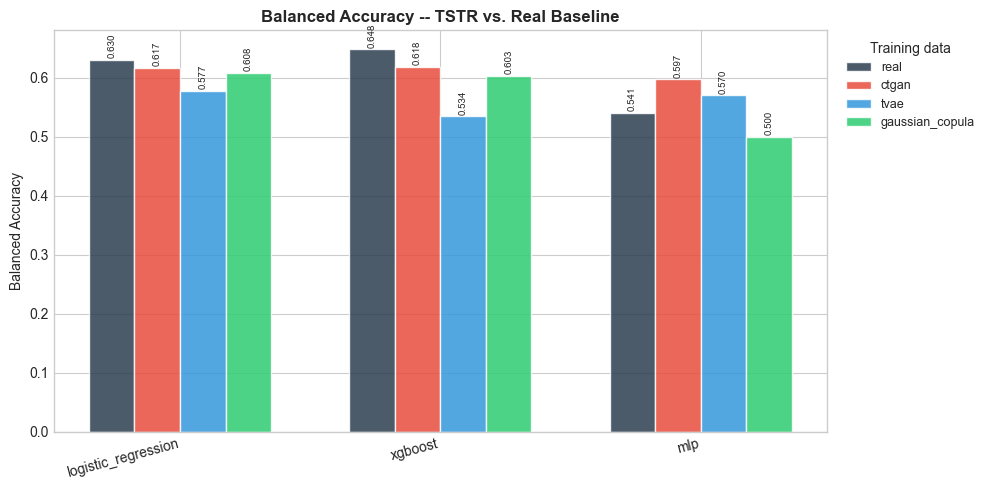

2026-07-10 19:16:20 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_f1_macro.png


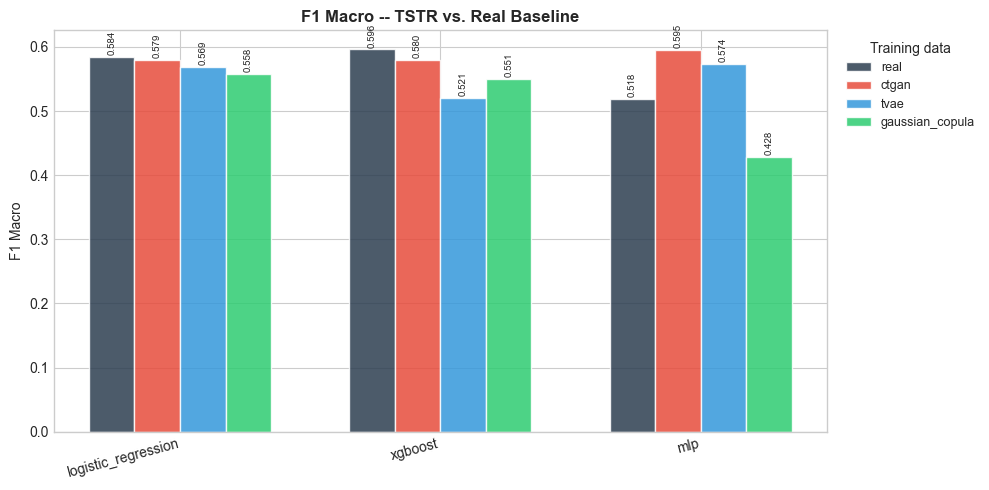

2026-07-10 19:16:21 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_roc_auc.png


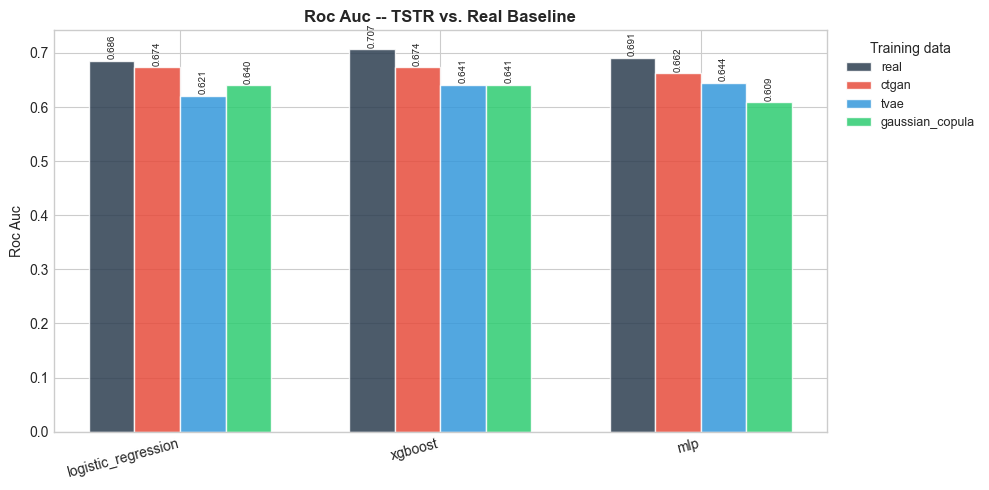

In [ ]:
for metric in ["balanced_accuracy", "f1_macro", "roc_auc"]:
    fig = plot_utility_bar(results_df, metric, cfg, save=True)
    plt.show()

2026-07-10 19:16:24 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\mmd_comparison.png


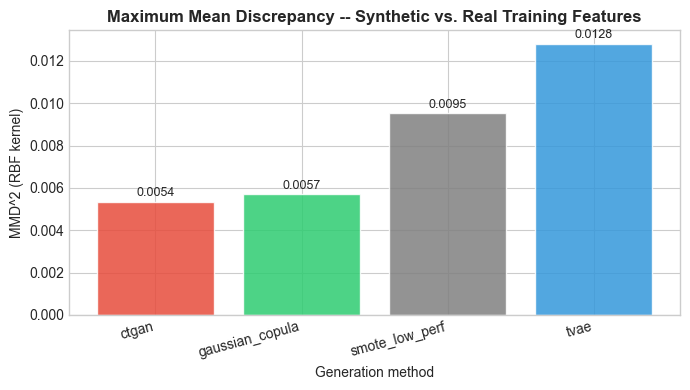


MMD summary (lower = synthetic distribution closer to real):
         method    mmd
          ctgan 0.0054
gaussian_copula 0.0057
 smote_low_perf 0.0095
           tvae 0.0128


In [ ]:
fig = plot_mmd_bar(results_df, cfg, save=True)
plt.show()

print("\nMMD summary (lower = synthetic distribution closer to real):")
mmd_summary = (results_df[results_df["method"] != BASELINE]
               .drop_duplicates("method")[["method","mmd"]]
               .sort_values("mmd"))
print(mmd_summary.round(4).to_string(index=False))

## 7 · Fairness Analysis

For each configured protected attribute (`config.yaml`'s `dataset.protected_attributes`,
intersected with the columns actually present in the data) and each
`(method, classifier)` combination we measure:

| Metric | Definition | Good value |
|--------|-----------|------------|
| **DPD** | \|Pr[Ŷ=1\|A=0] − Pr[Ŷ=1\|A=1]\| | close to 0 |
| **EOD** | max(\|ΔTPR\|, \|ΔFPR\|) | close to 0 |
| **DI** | Pr[Ŷ=1\|A=0] / Pr[Ŷ=1\|A=1] | ≥ 0.8 (four-fifths rule) |

We compare real-trained models with synth-trained models. A good generator
**preserves** the fairness profile of the real baseline — it neither improves
nor worsens it artificially.

In [ ]:
fairness_base_cols = ["method", "classifier"]
dpd_cols = [c for c in results_df.columns if c.endswith("_dpd") and not c.startswith("fairness")]
eod_cols = [c for c in results_df.columns if c.endswith("_eod") and not c.startswith("fairness")]
di_cols  = [c for c in results_df.columns if c.endswith("_di")  and not c.startswith("fairness")]
odds_cols = [c for c in results_df.columns if c.endswith("_odds_ratio") and not c.startswith("fairness")]
mean_cols = [c for c in ["mean_dpd","mean_eod","mean_di","mean_odds_ratio"] if c in results_df.columns]
gap_cols  = [c for c in results_df.columns if c.startswith("fairness_gap_")]

fairness_table = results_df[fairness_base_cols + dpd_cols + eod_cols + di_cols + odds_cols + mean_cols].copy()
print("Fairness metrics (all methods × classifiers):\n")
print(fairness_table.round(4).to_string(index=False))

Fairness metrics (all methods × classifiers):

         method          classifier  s_gender_dpd  f_mother_education_level_dpd  f_father_education_level_dpd  f_mother_occupation_dpd  f_father_occupation_dpd  f_extent_of_books_at_home_dpd  f_frequency_of_see_adult_read_dpd  f_ESCS_dpd  mean_dpd  s_gender_eod  f_mother_education_level_eod  f_father_education_level_eod  f_mother_occupation_eod  f_father_occupation_eod  f_extent_of_books_at_home_eod  f_frequency_of_see_adult_read_eod  f_ESCS_eod  mean_eod  s_gender_di  f_mother_education_level_di  f_father_education_level_di  f_mother_occupation_di  f_father_occupation_di  f_extent_of_books_at_home_di  f_frequency_of_see_adult_read_di  f_ESCS_di  mean_di  s_gender_odds_ratio  f_mother_education_level_odds_ratio  f_father_education_level_odds_ratio  f_mother_occupation_odds_ratio  f_father_occupation_odds_ratio  f_extent_of_books_at_home_odds_ratio  f_frequency_of_see_adult_read_odds_ratio  f_ESCS_odds_ratio  mean_odds_ratio  mean_dpd  mean

2026-07-10 19:16:25 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_dpd.png


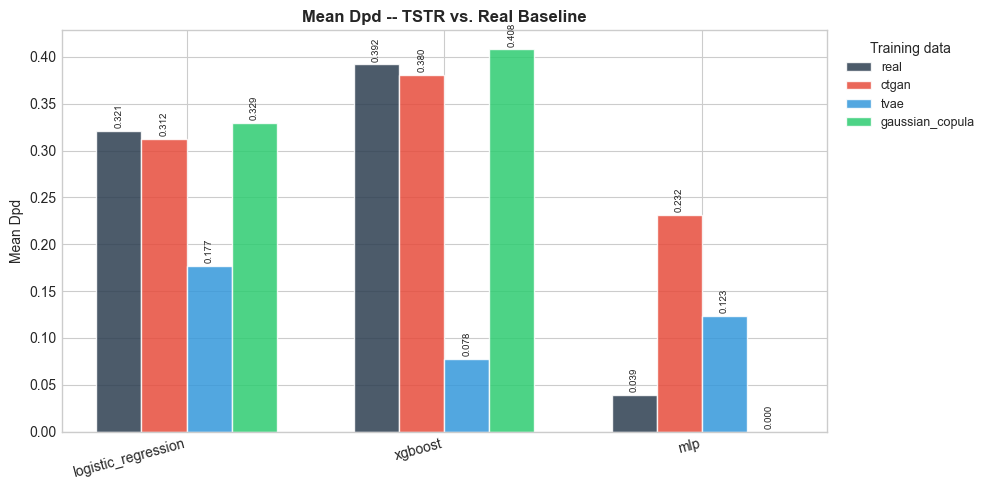

2026-07-10 19:16:29 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_eod.png


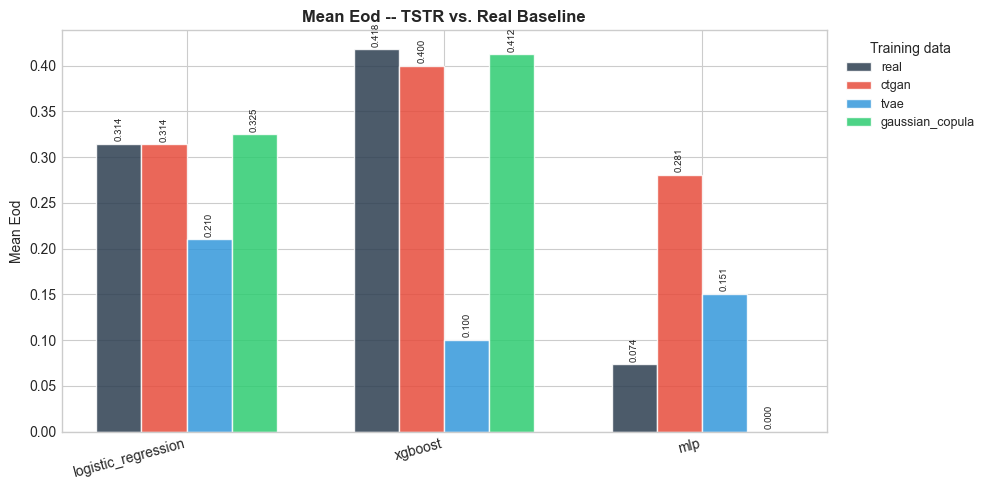

2026-07-10 19:16:31 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_di.png


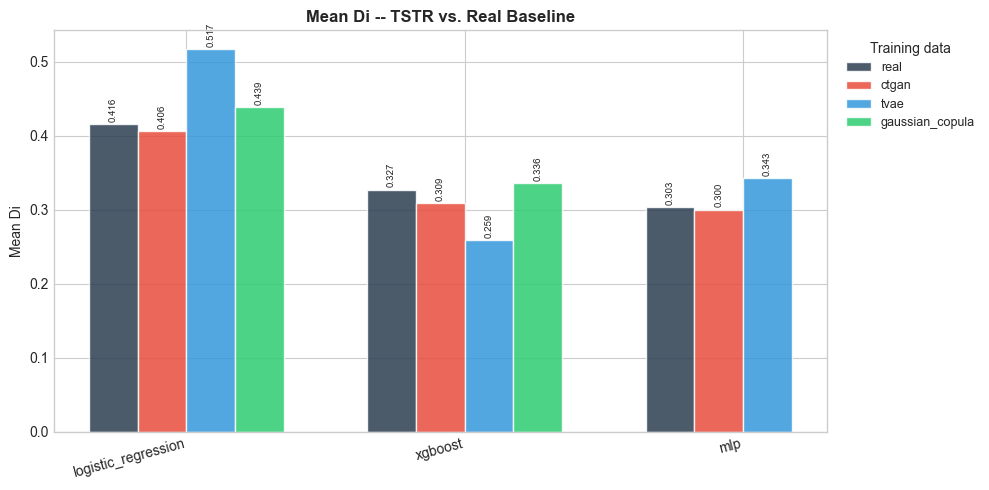

In [ ]:
# Per-attribute fairness bar charts
for metric in ["dpd", "eod", "di"]:
    if f"mean_{metric}" in results_df.columns:
        fig = plot_fairness_bar(results_df, f"mean_{metric}", cfg, save=True)
        plt.show()

2026-07-10 19:16:33 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_s_gender_dpd.png


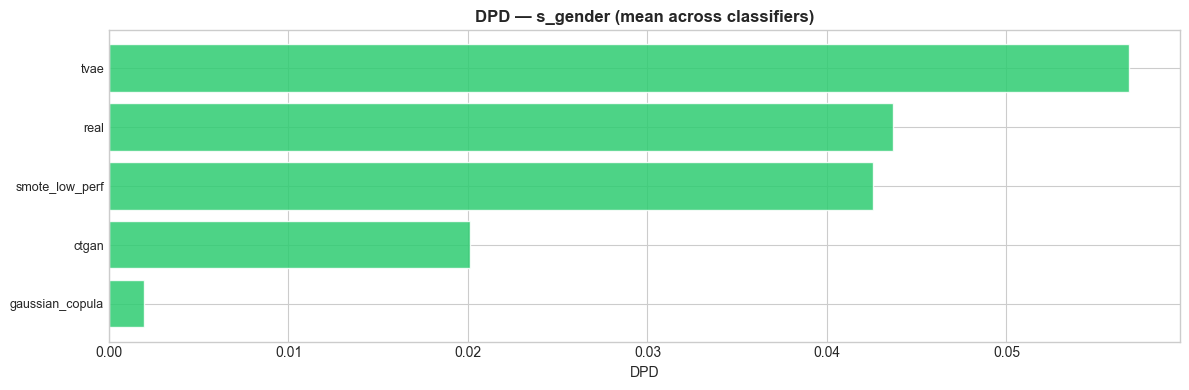

2026-07-10 19:16:35 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_s_gender_eod.png


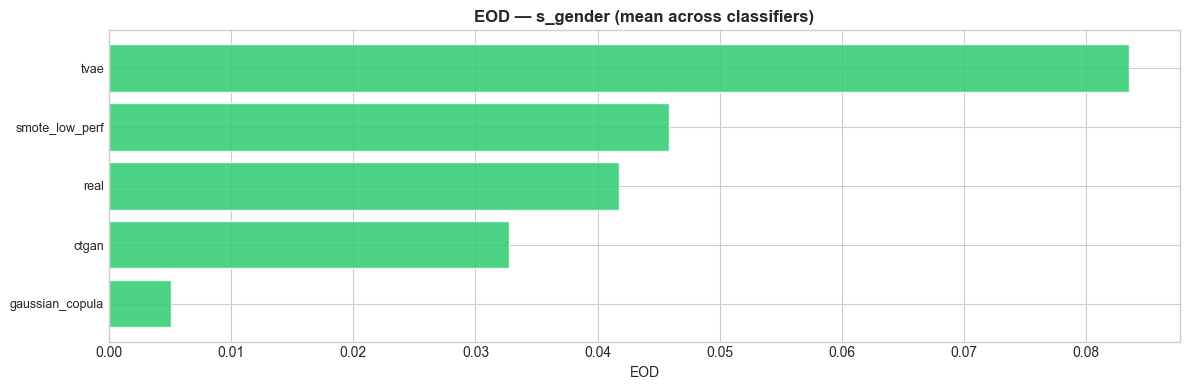

2026-07-10 19:16:36 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_s_gender_di.png


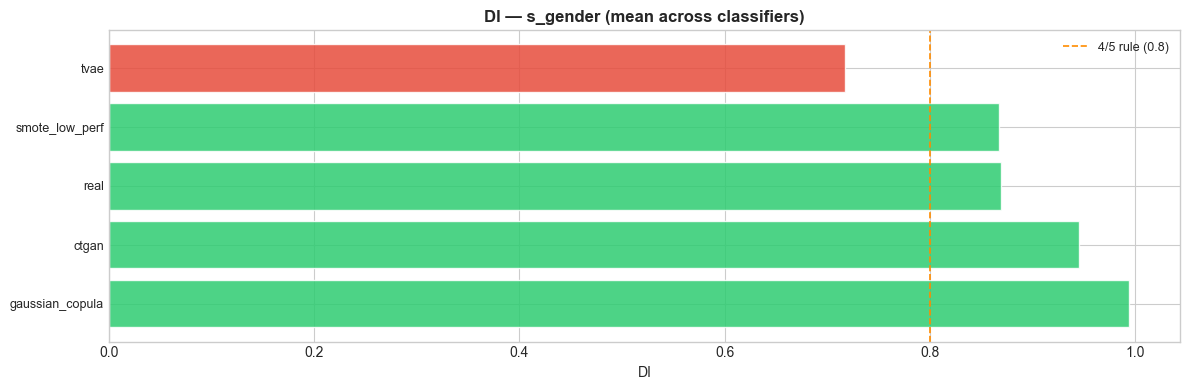

2026-07-10 19:16:38 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_f_mother_education_level_dpd.png


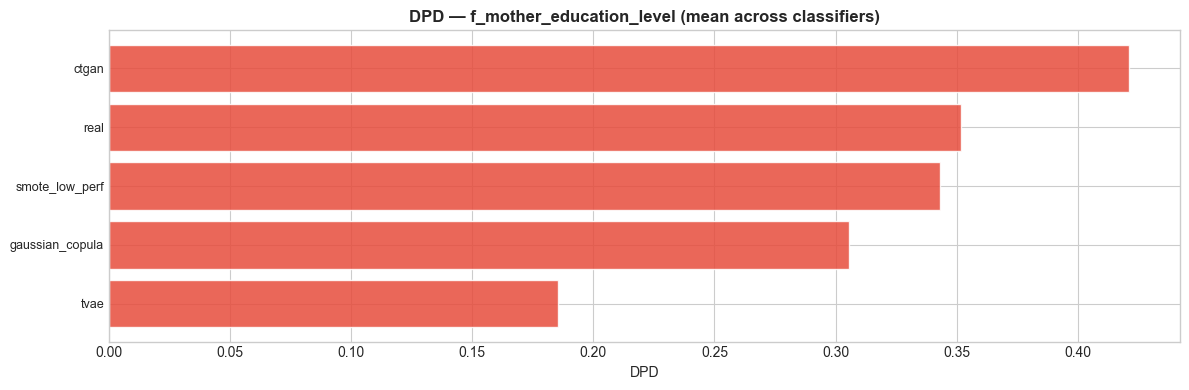

2026-07-10 19:16:39 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_f_mother_education_level_eod.png


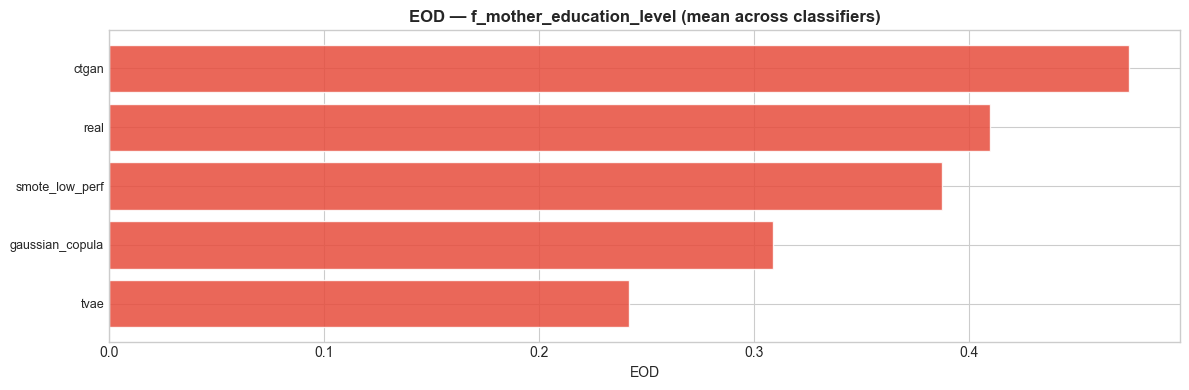

2026-07-10 19:16:40 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_f_mother_education_level_di.png


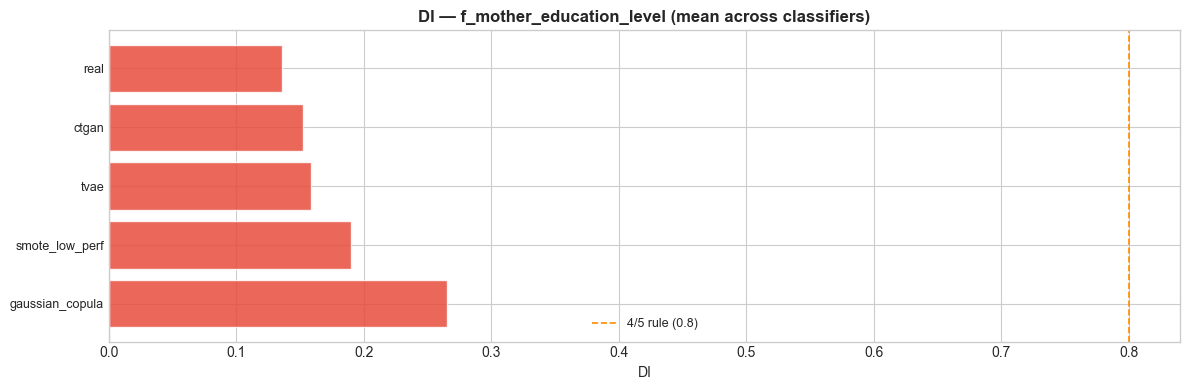

2026-07-10 19:16:41 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_f_father_education_level_dpd.png


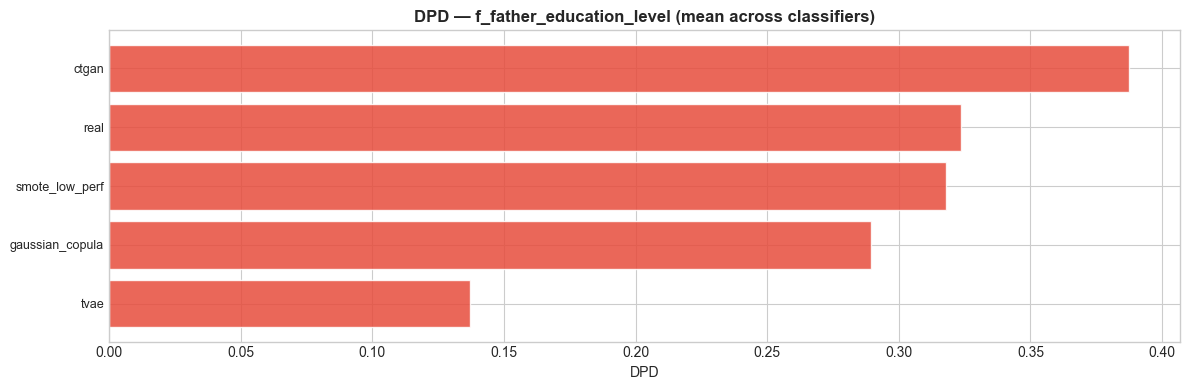

2026-07-10 19:16:42 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_f_father_education_level_eod.png


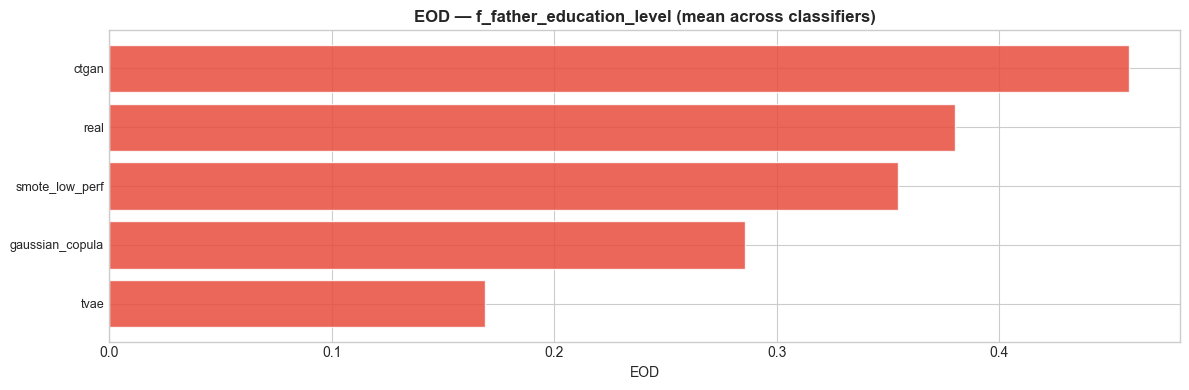

2026-07-10 19:16:43 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_f_father_education_level_di.png


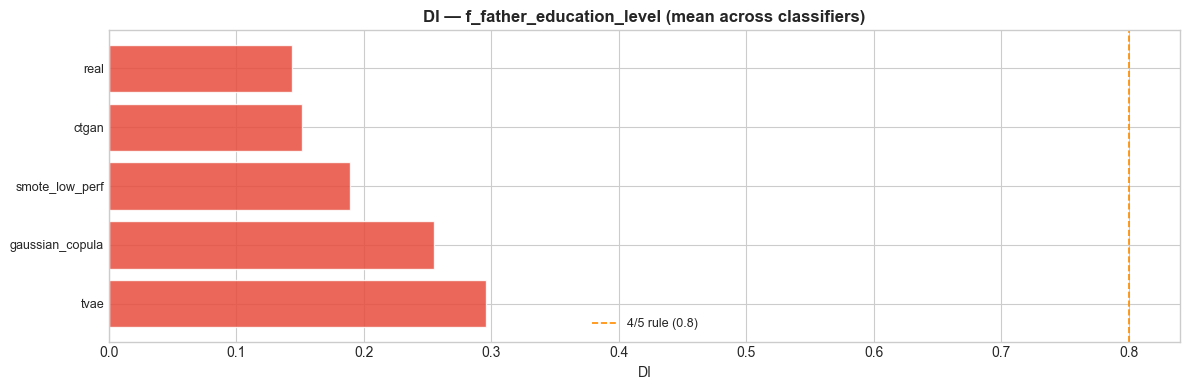

2026-07-10 19:16:44 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_f_mother_occupation_dpd.png


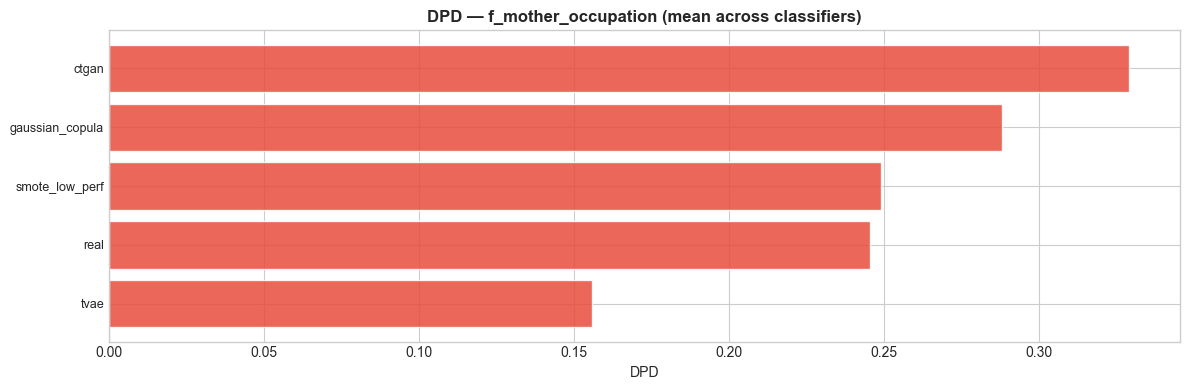

2026-07-10 19:16:45 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_f_mother_occupation_eod.png


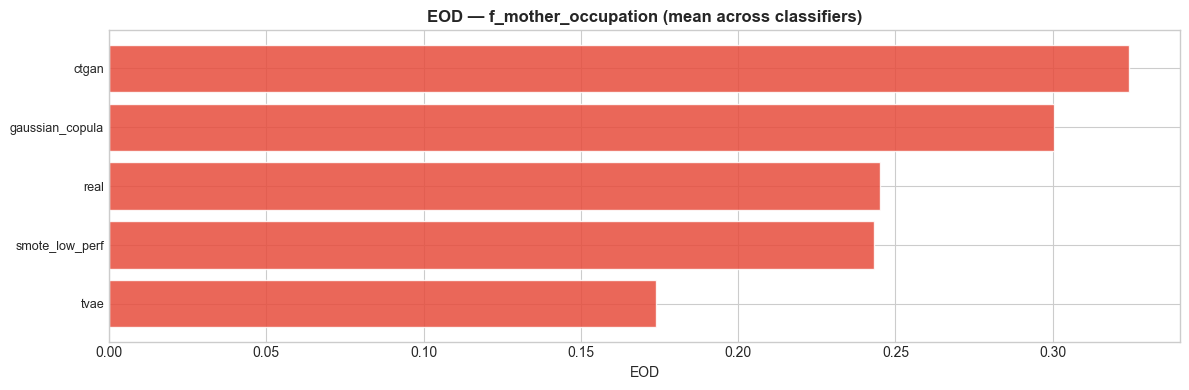

2026-07-10 19:16:46 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_f_mother_occupation_di.png


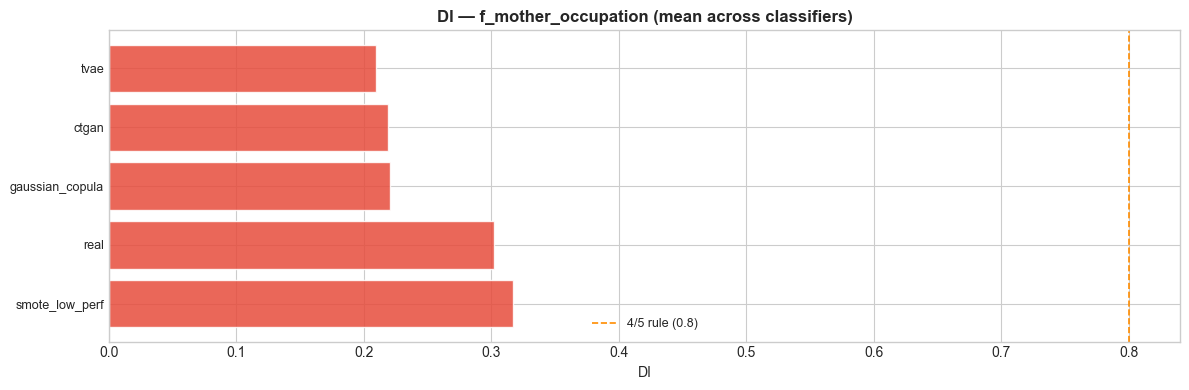

2026-07-10 19:16:47 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_f_father_occupation_dpd.png


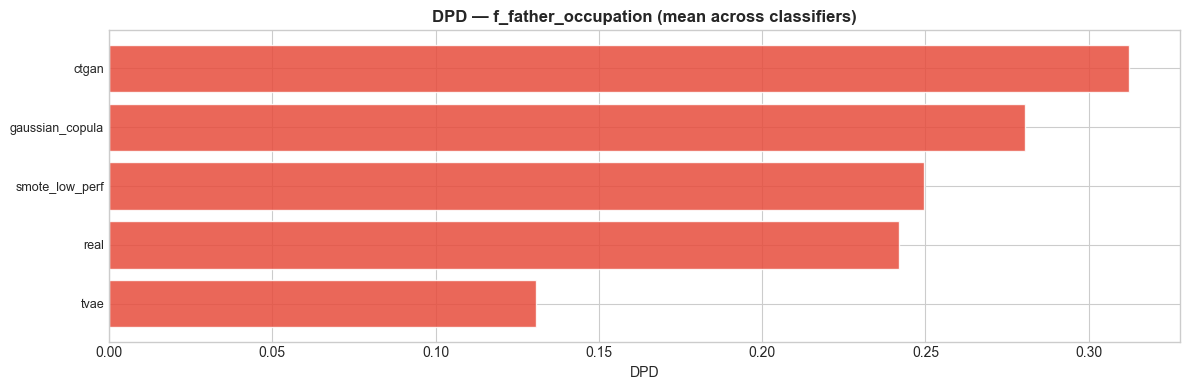

2026-07-10 19:16:48 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_f_father_occupation_eod.png


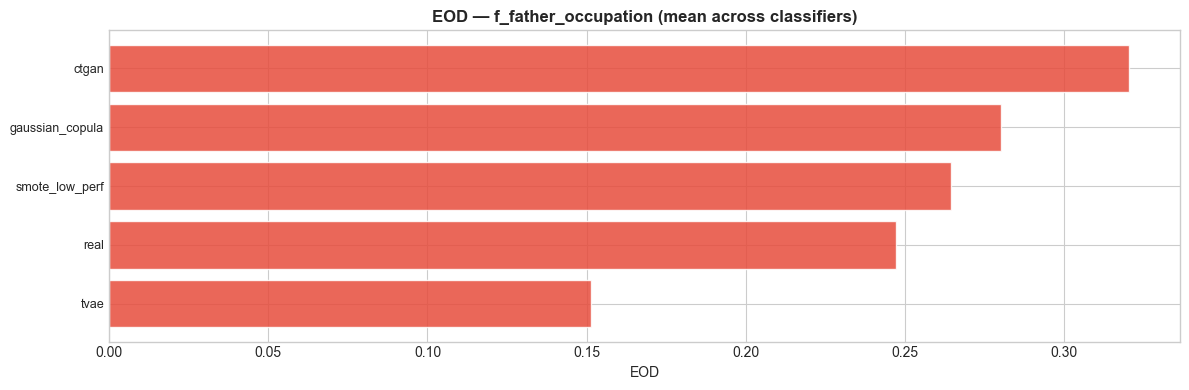

2026-07-10 19:16:49 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_f_father_occupation_di.png


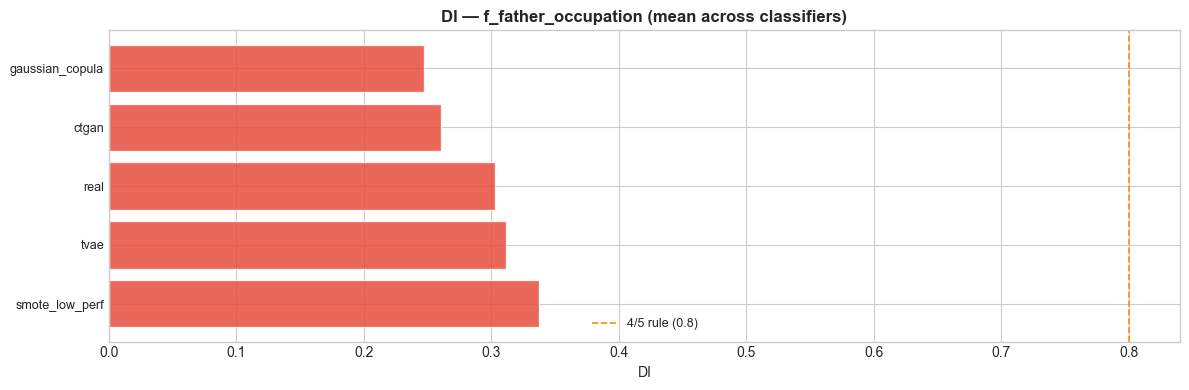

2026-07-10 19:16:51 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_f_extent_of_books_at_home_dpd.png


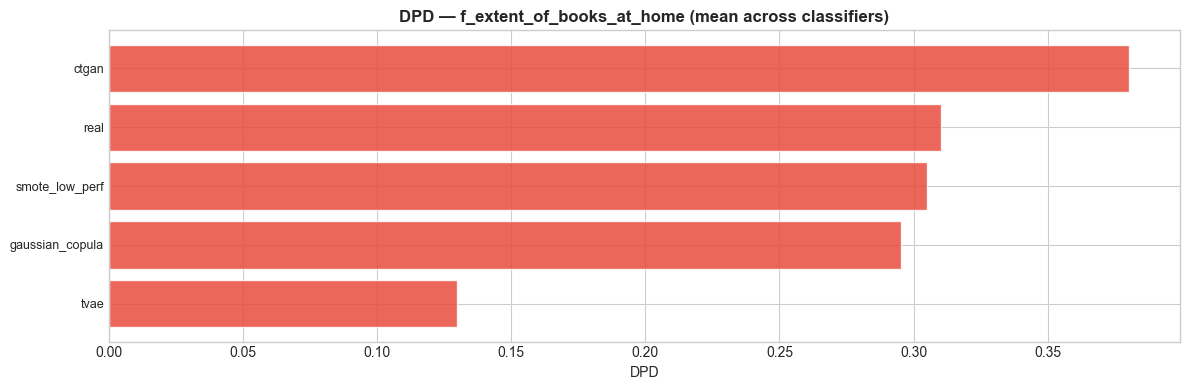

2026-07-10 19:16:51 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_f_extent_of_books_at_home_eod.png


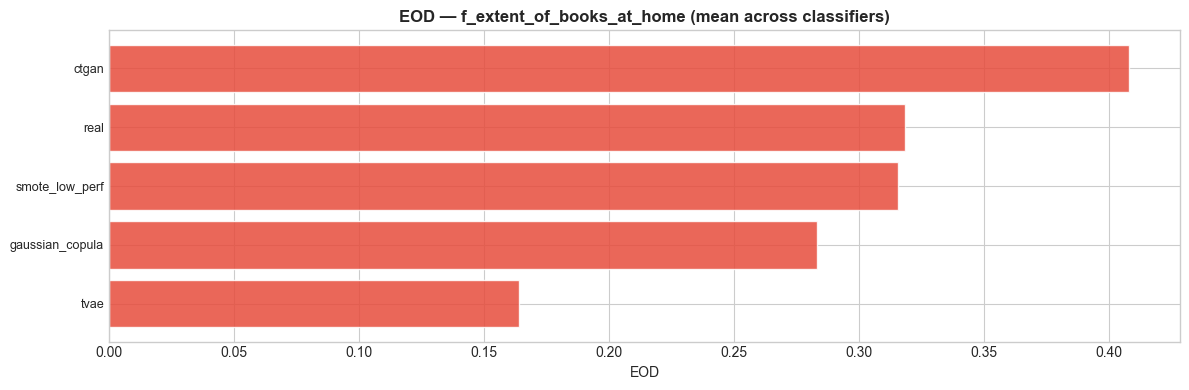

2026-07-10 19:16:52 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_f_extent_of_books_at_home_di.png


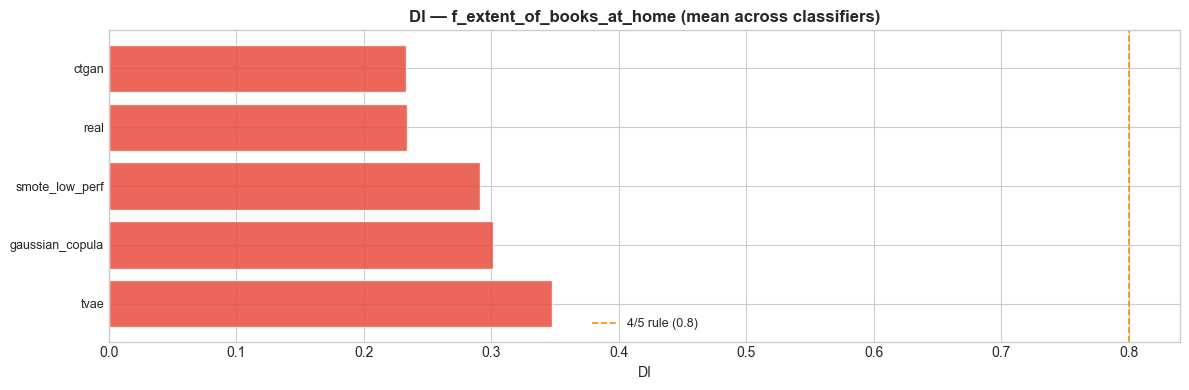

2026-07-10 19:16:53 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_f_frequency_of_see_adult_read_dpd.png


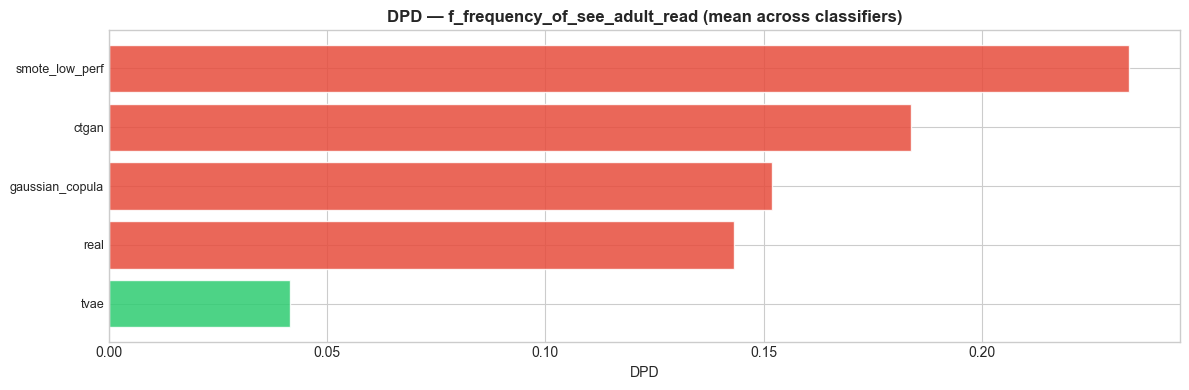

2026-07-10 19:16:53 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_f_frequency_of_see_adult_read_eod.png


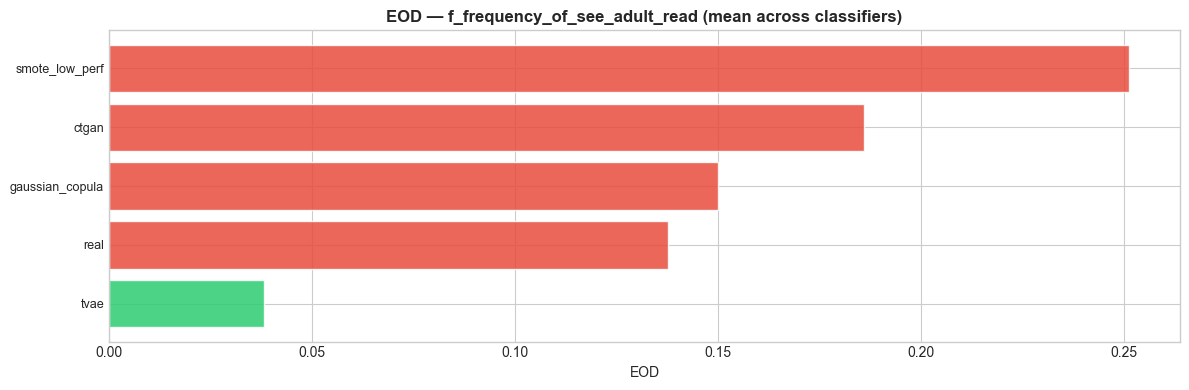

2026-07-10 19:17:00 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_f_frequency_of_see_adult_read_di.png


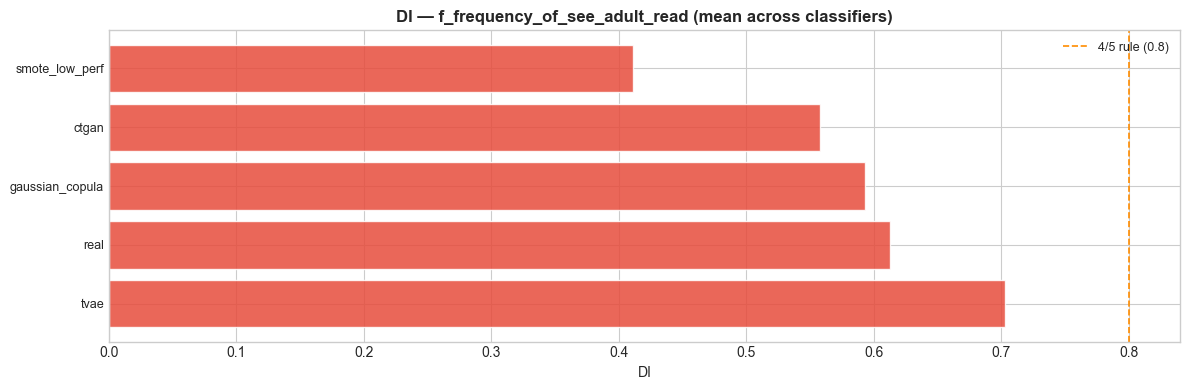

2026-07-10 19:17:01 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_f_ESCS_dpd.png


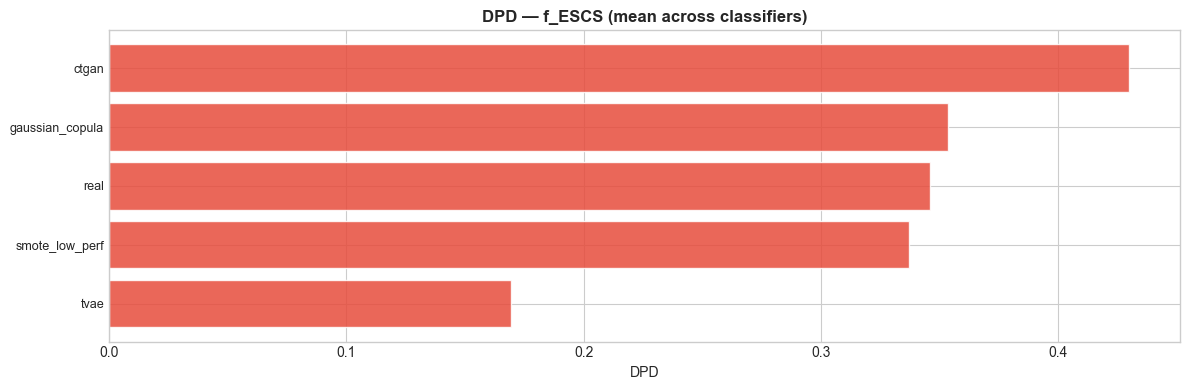

2026-07-10 19:17:01 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_f_ESCS_eod.png


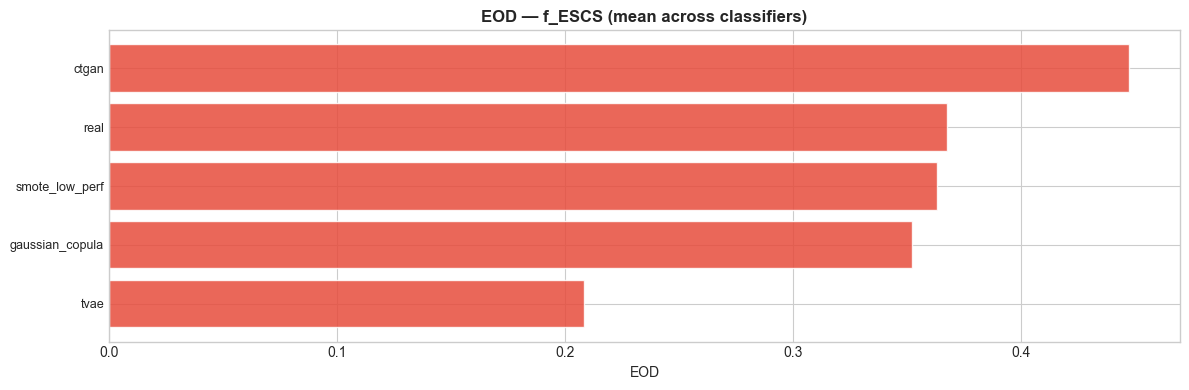

2026-07-10 19:17:02 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_f_ESCS_di.png


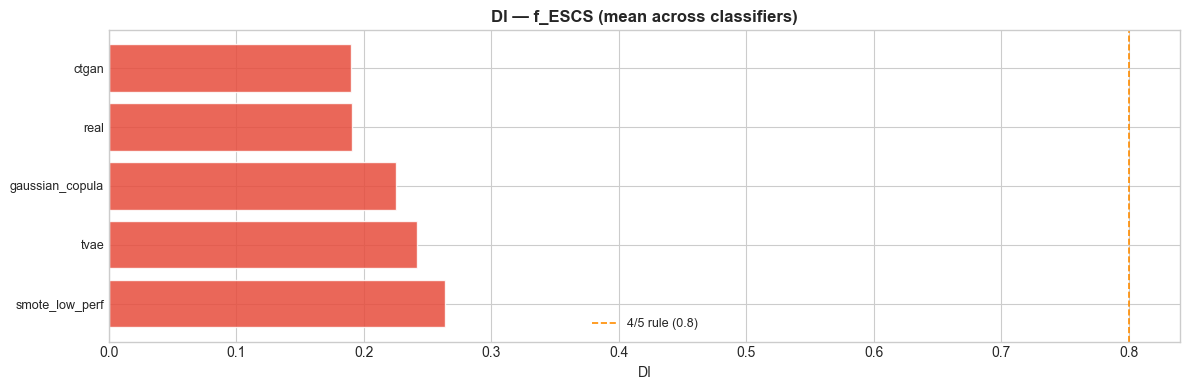

In [ ]:
# Per-attribute breakdown (one chart per attr × metric)
for attr in PROTECTED_COLS:
    attr_rows = []
    for method in [BASELINE] + list(synthetic_data.keys()):
        sub = results_df[results_df["method"] == method]
        if sub.empty:
            continue
        for metric in ("dpd", "eod", "di"):
            col = f"{attr}_{metric}"
            if col in sub.columns:
                attr_rows.append({
                    "attribute": f"{method}",
                    metric: sub[col].mean(),   # mean across classifiers
                })
    if not attr_rows:
        continue
    attr_df = pd.DataFrame(attr_rows).groupby("attribute").mean().reset_index()

    for metric in ("dpd", "eod", "di"):
        if metric not in attr_df.columns:
            continue
        fig = plot_per_attribute_fairness(
            attr_df, metric, cfg,
            title=f"{metric.upper()} — {attr} (mean across classifiers)",
            filename_suffix=f"_{attr}_{metric}",
            save=True,
        )
        plt.show()

### Delta heatmaps

The heatmaps below show how each synthetic generator shifts utility and fairness
**relative to the real-data baseline**. Red = degradation relative to real; blue = improvement.

- For utility metrics (BA, F1, AUC): positive delta means the real model was better
  (i.e. synthetic training hurt). Red cells = utility loss.
- For fairness metrics (`delta_mean_dpd`, `delta_mean_eod`, `delta_mean_di`, from
  `src.evaluation.delta.compute_delta_matrix`): any non-zero value means the synthetic
  generator altered the fairness profile of the model relative to real data.

2026-07-10 19:17:04 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\delta_heatmap_utility.png


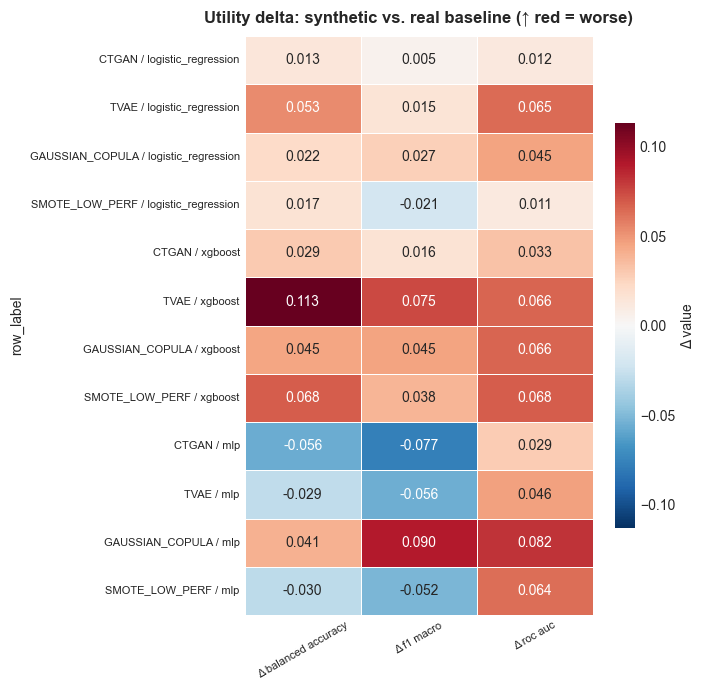

In [ ]:
# Utility delta heatmap
delta_utility_cols = ["delta_balanced_accuracy", "delta_f1_macro", "delta_roc_auc"]
delta_utility_cols = [c for c in delta_utility_cols if c in results_df.columns]

if delta_utility_cols:
    fig = plot_delta_heatmap(
        results_df[results_df["method"] != BASELINE],
        delta_utility_cols,
        filename_suffix="utility",
        cfg=cfg,
        title="Utility delta: synthetic vs. real baseline (↑ red = worse)",
        save=True,
    )
    plt.show()

2026-07-10 19:17:06 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\delta_heatmap_fairness.png


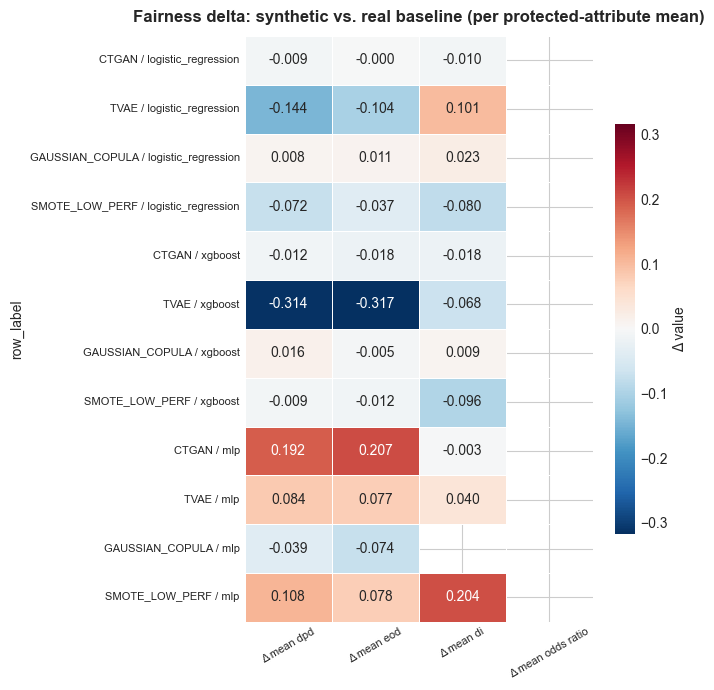

In [ ]:
# Fairness delta heatmap (relative to real baseline, per classifier)
delta_df = compute_delta_matrix(results_df, cfg)
fairness_delta_cols = get_fairness_delta_columns(delta_df)

if fairness_delta_cols:
    fig = plot_delta_heatmap(
        delta_df[delta_df["method"] != BASELINE],
        fairness_delta_cols,
        filename_suffix="fairness",
        cfg=cfg,
        title="Fairness delta: synthetic vs. real baseline (per protected-attribute mean)",
        save=True,
    )
    plt.show()
else:
    print("No fairness delta columns found — check that protected attrs were set correctly.")

2026-07-10 19:17:07 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\scatter_utility_vs_fairness.png


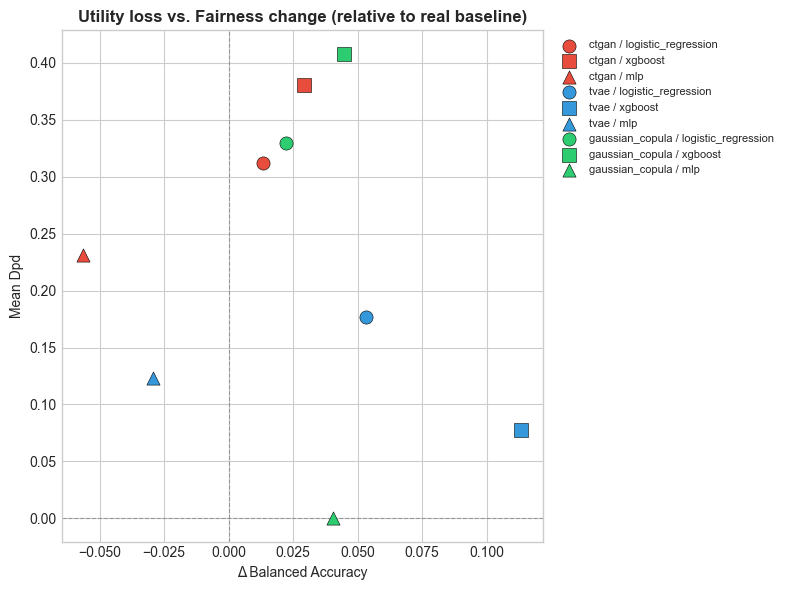

Points close to (0, 0) are Pareto-optimal: no utility loss, no fairness shift.


In [ ]:
# Utility vs. fairness scatter (the key trade-off plot for the report)
if "mean_dpd" in results_df.columns:
    fig = plot_utility_fairness_scatter(
        results_df,
        utility_col  = "delta_balanced_accuracy",
        fairness_col = "mean_dpd",
        cfg          = cfg,
        save         = True,
    )
    plt.show()
    print("Points close to (0, 0) are Pareto-optimal: no utility loss, no fairness shift.")

## 8 · Fairness Mitigation

Everything above measures fairness on classifiers trained *without* any
mitigation. This section retrains/post-processes each `(method, classifier)`
combination **with** a mitigation technique applied against **one protected
attribute at a time** (`PROTECTED_COLS`), still under the same TSTR setup:
train on real or synthetic data, score against the fixed real test set.

Two independent techniques (`src/evaluation/mitigation.py`, driven by
`MitigatedEvaluator`):

| Technique | Type | Scope | How it works |
|---|---|---|---|
| **Equalized odds** | Post-processing | Wraps any of the 3 classifiers | [fairlearn](https://fairlearn.org/) `ThresholdOptimizer` picks group-aware decision thresholds, after normal training, to equalize TPR/FPR across the two groups of the target attribute. |
| **Prejudice remover** | In-processing | Its own model (classifier-agnostic) | [aif360](https://aif360.res.ibm.com/) `PrejudiceRemover` (Kamishima et al., 2012) — a regularised logistic-regression-style model whose loss directly penalises mutual information between predictions and the sensitive attribute. |

Both use the same group definition that `fairness.py` uses to *measure*
DPD/EOD/DI (median-split / direct binary mapping), so "mitigated for attribute
X" and "X's fairness metrics" always refer to the same grouping.

Fully **revertible**: set `mitigation.enabled: false` in `config.yaml` to skip
this entire section (the rest of the notebook is unaffected). `mitigation.methods`
lets you run only one of the two techniques; `equalized_odds.grid_size` and
`prejudice_remover.eta` control technique-specific trade-offs.

> **Note on AUC/Brier for mitigated rows:** equalized-odds predictions are
> hard 0/1 labels (no calibrated probability), so `roc_auc`/`brier_score` on
> those rows are computed from the hard label itself — a coarser score than
> the unmitigated rows. Prejudice Remover does expose a real probability, so
> its AUC/Brier are directly comparable to the unmitigated baseline.

In [ ]:
mitigation_cfg = cfg.get("mitigation", {})
mitigation_rows = []
mitigation_path = cfg["paths"]["results_dir"] / "goal3_mitigation_results.csv"
mitigation_path.parent.mkdir(parents=True, exist_ok=True)

if mitigation_cfg.get("enabled", False) and PROTECTED_COLS:
    mitigated_evaluator = MitigatedEvaluator(split, cfg)
    techniques = mitigation_cfg.get("methods", ["equalized_odds", "prejudice_remover"])

    # Same "method" axis as the unmitigated TSTR loop: real baseline + every
    # loaded synthetic generator, all trained against the fixed real test set.
    # Each source carries its OWN protected-attribute values (3rd tuple elem)
    # -- a synthetic training set can have a different row count than the real
    # training set (e.g. SMOTE's class-balanced output), so split.protected_train
    # can't be reused for those rows.
    train_sources = {
        BASELINE: (split.X_train, split.y_train, split.protected_train),
        **synthetic_data,
    }

    n_eo = len(CLASSIFIERS) if "equalized_odds" in techniques else 0
    n_pr = 1 if "prejudice_remover" in techniques else 0
    logger.info(
        f"Mitigation loop: {len(PROTECTED_COLS)} attrs x {len(train_sources)} methods x "
        f"({n_eo} EO classifiers + {n_pr} PR model) = "
        f"{len(PROTECTED_COLS) * len(train_sources) * (n_eo + n_pr)} fits"
    )

    # A sensitive-attribute subgroup can end up with zero label variance in a
    # synthetic training set -- SMOTE only interpolates within the minority
    # class, so if one subgroup had few/no minority-class rows to begin with,
    # it can come out of resampling 100% one label. Neither ThresholdOptimizer
    # nor PrejudiceRemover can fit a fairness constraint against a group with
    # no label variance, so this is a real, reportable failure mode (same
    # spirit as the TVAE minority-collapse discussion in Notebook 02), not a
    # bug to hide -- we record it as a NaN/flagged row and keep going, rather
    # than let one degenerate combination discard the whole (many-minute) run.
    for attr in PROTECTED_COLS:
        for method, (X_tr, y_tr, protected_tr) in train_sources.items():
            attr_train = protected_tr[attr]
            if "equalized_odds" in techniques:
                for clf_name in CLASSIFIERS:
                    try:
                        row = mitigated_evaluator.evaluate(
                            X_tr, y_tr,
                            technique      = "equalized_odds",
                            target_attr    = attr,
                            method_name    = method,
                            attr_train     = attr_train,
                            classifier_name= clf_name,
                        )
                    except ValueError as e:
                        logger.warning(f"  [EO | {attr} | {method} | {clf_name}]  SKIPPED — {e}")
                        row = {
                            "technique": "equalized_odds", "target_attr": attr,
                            "method": method, "classifier": clf_name,
                            "balanced_accuracy": float("nan"), "error": str(e),
                        }
                    mitigation_rows.append(row)
                    print(f"  [EO | {attr} | {method} | {clf_name}]  "
                          f"BA={row['balanced_accuracy']:.4f}  mean_DPD={row.get('mean_dpd', float('nan')):.4f}")

            if "prejudice_remover" in techniques:
                try:
                    row = mitigated_evaluator.evaluate(
                        X_tr, y_tr,
                        technique  = "prejudice_remover",
                        target_attr= attr,
                        method_name= method,
                        attr_train = attr_train,
                    )
                except ValueError as e:
                    logger.warning(f"  [PR | {attr} | {method}]  SKIPPED — {e}")
                    row = {
                        "technique": "prejudice_remover", "target_attr": attr,
                        "method": method, "classifier": "prejudice_remover",
                        "balanced_accuracy": float("nan"), "error": str(e),
                    }
                mitigation_rows.append(row)
                print(f"  [PR | {attr} | {method}]  "
                      f"BA={row['balanced_accuracy']:.4f}  mean_DPD={row.get('mean_dpd', float('nan')):.4f}")

            # Checkpoint after every (attr, method) pair so a later failure
            # never discards fits that already completed.
            pd.DataFrame(mitigation_rows).to_csv(mitigation_path, index=False)

    mitigation_df = pd.DataFrame(mitigation_rows)
    mitigation_df.to_csv(mitigation_path, index=False)
    n_failed = mitigation_df["error"].notna().sum() if "error" in mitigation_df.columns else 0
    print(f"\nMitigation results saved → {mitigation_path}")
    print(f"Shape: {mitigation_df.shape}  ({n_failed} degenerate/skipped fits, if any)")
else:
    mitigation_df = pd.DataFrame()
    print("Mitigation section disabled or no protected attributes present "
          "(mitigation.enabled: false, or PROTECTED_COLS is empty) — skipping.")

mitigation_df.head(10)

2026-07-10 19:17:09 | INFO     | notebook_03 | Mitigation loop: 8 attrs x 5 methods x (3 EO classifiers + 1 PR model) = 160 fits


2026-07-10 19:17:12 | INFO     | src.evaluation.evaluator |   [mitigated:equalized_odds | target=s_gender | real | logistic_regression] BA=0.6273 | mean_dpd=0.3392
  [EO | s_gender | real | logistic_regression]  BA=0.6273  mean_DPD=0.3392
2026-07-10 19:17:20 | INFO     | src.evaluation.evaluator |   [mitigated:equalized_odds | target=s_gender | real | xgboost] BA=0.6435 | mean_dpd=0.3574
  [EO | s_gender | real | xgboost]  BA=0.6435  mean_DPD=0.3574
2026-07-10 19:17:41 | INFO     | src.evaluation.evaluator |   [mitigated:equalized_odds | target=s_gender | real | mlp] BA=0.6304 | mean_dpd=0.3104
  [EO | s_gender | real | mlp]  BA=0.6304  mean_DPD=0.3104
2026-07-10 19:20:19 | INFO     | src.evaluation.evaluator |   [mitigated:prejudice_remover | target=s_gender | real | prejudice_remover] BA=0.5383 | mean_dpd=0.0365
  [PR | s_gender | real]  BA=0.5383  mean_DPD=0.0365
2026-07-10 19:20:22 | INFO     | src.evaluation.evaluator |   [mitigated:equalized_odds | target=s_gender | ctgan | logis

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

### Mitigation summary tables

For every mitigated row we look up the **matching unmitigated row** from
`results_df` (same `method`, and for equalized-odds the same `classifier`) and
compare the targeted attribute's own DPD/EOD/DI before vs. after mitigation —
this answers "did mitigating for attribute X actually reduce unfairness on
X?", as opposed to the mean-across-all-attributes numbers used elsewhere in
the notebook.

In [ ]:
def _unmitigated_target_metrics(method: str, classifier: str | None, attr: str) -> dict[str, float]:
    """Mean dpd/eod/di for `attr` from the unmitigated results_df, matched on
    method (+ classifier when given -- prejudice_remover has no match, so we
    average across all classifiers for that method instead)."""
    sub = results_df[results_df["method"] == method]
    if classifier is not None:
        sub = sub[sub["classifier"] == classifier]
    out = {}
    for metric in ("dpd", "eod", "di"):
        col = f"{attr}_{metric}"
        out[metric] = sub[col].mean() if col in sub.columns and not sub.empty else float("nan")
    return out


comparison_rows = []
for _, r in mitigation_df.iterrows():
    attr = r["target_attr"]
    clf_lookup = r["classifier"] if r["technique"] == "equalized_odds" else None
    base = _unmitigated_target_metrics(r["method"], clf_lookup, attr)

    row = {
        "technique": r["technique"], "target_attr": attr,
        "method": r["method"], "classifier": r["classifier"],
        "balanced_accuracy": r["balanced_accuracy"],
    }
    for metric in ("dpd", "eod", "di"):
        mitigated_val = r.get(f"{attr}_{metric}", float("nan"))
        row[f"{metric}_unmitigated"] = base[metric]
        row[f"{metric}_mitigated"]   = mitigated_val
        # DPD/EOD: lower is fairer -> improvement = unmitigated - mitigated.
        # DI: closer to 1 is fairer -> improvement = mitigated - unmitigated.
        if metric == "di":
            row[f"{metric}_improvement"] = mitigated_val - base[metric]
        else:
            row[f"{metric}_improvement"] = base[metric] - mitigated_val
    comparison_rows.append(row)

mitigation_comparison_df = pd.DataFrame(comparison_rows)
if not mitigation_comparison_df.empty:
    comparison_path = cfg["paths"]["results_dir"] / "goal3_mitigation_comparison.csv"
    mitigation_comparison_df.to_csv(comparison_path, index=False)
    print(f"Mitigation comparison saved → {comparison_path}\n")
    print(mitigation_comparison_df.round(4).to_string(index=False))
else:
    print("No mitigation rows to compare (mitigation disabled or no protected attributes present).")

In [ ]:
# Summary table 1: overall effectiveness per technique (mean across every
# attribute/method/classifier it was run on).
if not mitigation_comparison_df.empty:
    print("Mean fairness improvement by technique (positive = fairer than unmitigated):\n")
    by_technique = mitigation_comparison_df.groupby("technique")[
        ["balanced_accuracy", "dpd_improvement", "eod_improvement", "di_improvement"]
    ].mean()
    print(by_technique.round(4).to_string())
else:
    by_technique = pd.DataFrame()

In [ ]:
# Summary table 2: best technique per protected attribute, by mean DPD improvement.
if not mitigation_comparison_df.empty:
    by_attr_technique = (
        mitigation_comparison_df
        .groupby(["target_attr", "technique"])[["balanced_accuracy", "dpd_improvement", "eod_improvement", "di_improvement"]]
        .mean()
        .round(4)
    )
    print("Mean fairness improvement by (attribute, technique):\n")
    print(by_attr_technique.to_string())

    print("\nBest technique per attribute (highest mean DPD improvement):\n")
    best_per_attr = (
        mitigation_comparison_df
        .groupby(["target_attr", "technique"])["dpd_improvement"]
        .mean()
        .reset_index()
        .sort_values("dpd_improvement", ascending=False)
        .drop_duplicates("target_attr")
        .sort_values("target_attr")
    )
    print(best_per_attr.round(4).to_string(index=False))
else:
    by_attr_technique = pd.DataFrame()
    best_per_attr = pd.DataFrame()

## 9 · Summary

In [ ]:
print("=" * 70)
print("GOAL 3 SUMMARY")
print("=" * 70)

if not results_df.empty:
    synth = results_df[results_df["method"] != BASELINE]
    real  = results_df[results_df["method"] == BASELINE]

    mean_real_ba = real["balanced_accuracy"].mean()
    print(f"\nReal baseline (mean BA across classifiers): {mean_real_ba:.4f}")

    print("\nMean balanced accuracy per synthetic method (mean across classifiers):")
    tbl = synth.groupby("method")["balanced_accuracy"].mean().sort_values(ascending=False)
    for m, v in tbl.items():
        print(f"  {m:<20}  BA={v:.4f}  (Δ={v - mean_real_ba:+.4f})")

    if "mean_dpd" in synth.columns:
        print("\nMean DPD per synthetic method (mean across classifiers):")
        for m, v in synth.groupby("method")["mean_dpd"].mean().sort_values().items():
            print(f"  {m:<20}  mean_DPD={v:.4f}")

    if "mean_odds_ratio" in synth.columns:
        print("\nMean equalized-odds odds-ratio per synthetic method (mean across classifiers, ~1.0 = fair):")
        for m, v in synth.groupby("method")["mean_odds_ratio"].mean().items():
            print(f"  {m:<20}  mean_odds_ratio={v:.4f}")

if not mitigation_comparison_df.empty:
    print("\n" + "-" * 70)
    print("MITIGATION SUMMARY")
    print("-" * 70)
    for technique, row in by_technique.iterrows():
        print(f"  {technique:<20}  BA={row['balanced_accuracy']:.4f}  "
              f"ΔDPD={row['dpd_improvement']:+.4f}  ΔEOD={row['eod_improvement']:+.4f}  ΔDI={row['di_improvement']:+.4f}")
    print("\n  Best technique per attribute (by mean DPD improvement):")
    for _, row in best_per_attr.iterrows():
        print(f"    {row['target_attr']:<25}  {row['technique']:<20}  ΔDPD={row['dpd_improvement']:+.4f}")
    print(f"\n  Full comparison saved to: {cfg['paths']['results_dir'] / 'goal3_mitigation_comparison.csv'}")

print("\nAll figures saved to:", cfg["paths"]["figures_dir"])
print("Results CSV saved to:", cfg["paths"]["results_dir"] / "goal3_results.csv")